In [1]:
import numpy as np
import pandas as pd


from pmbrl.model import *
from pmbrl.data import *


# TESTE

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:168: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.deprecation(
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/gymnasium/utils/passive_env_checker.py:181: DeprecationWarning: WARN: Current gymnasium version requires that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.deprecation(


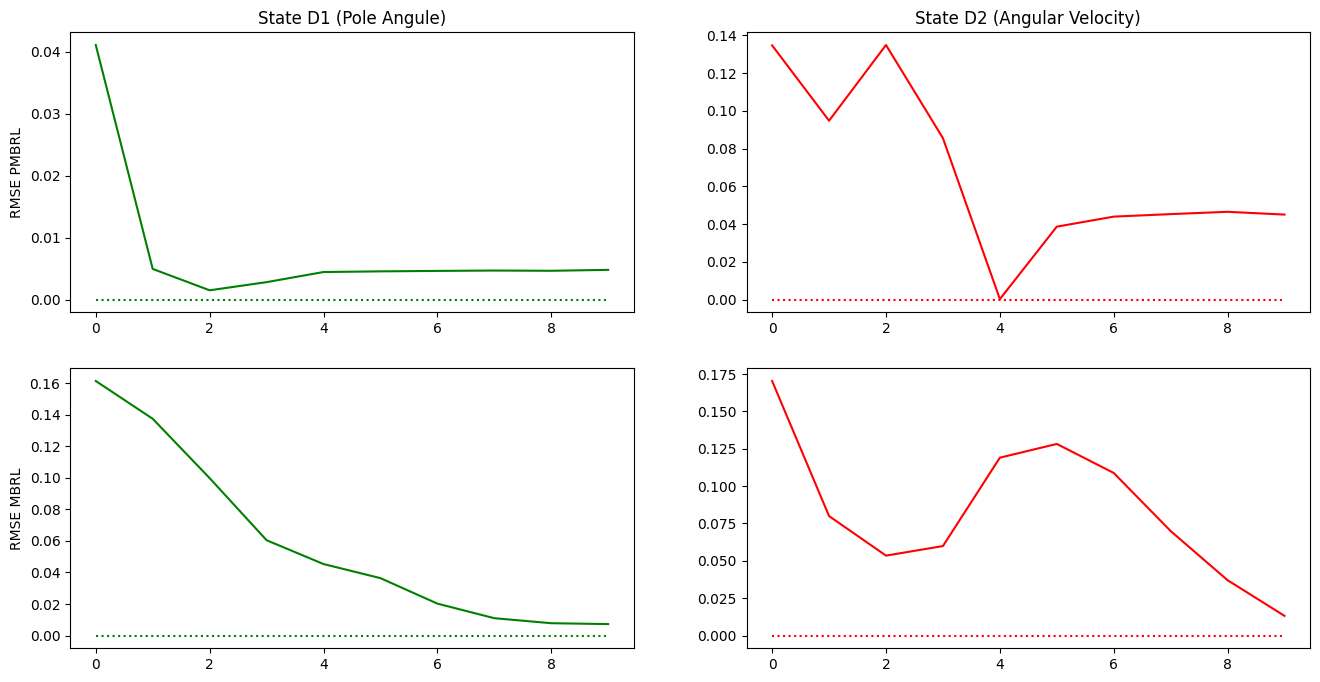

In [2]:
import matplotlib.pyplot as plt
import numpy as np


params = {
    # Models:
    "mode": "all", # Mode of the PMBRL (All: learn parameters and Transitions)
    
    #Dataset:
    "n":1000, # Number of steps on historic data
    "m":10, # Min Number of changes in environmental parameters

    #Traning:
    "num_epochs": 100, # Number of epochs on training
    "learning_rate": 0.001 # Learning rate of training
}

hist_s, hist_a, hist_p = generate_hist(n=params['n'], m=params['m'])
X_train, y_train, _, _ = train_test_split(hist_s, hist_a, hist_p, mode=params['mode'], p=0)
models = {
    'pmbrl' : Model(learning_rate=params['learning_rate']),
    'mbrl' : ModelBase(learning_rate=params['learning_rate'])
}

def iterate(m):
    m.train(X_train[:-1], y_train[:-1], num_epochs=params['num_epochs'], debug=False, mode=params['mode'])
    pred = m.sample(X_train[-1:], mode=params['mode'])
    return torch.mean((pred - y_train[-1:])**2, axis=0)**.5


fig, axs = plt.subplots(2, 2, figsize=(16, 8))

axs[0][0].set_title('State D1 (Pole Angule)')
axs[0][1].set_title('State D2 (Angular Velocity)')

axs[0][0].set_ylabel('RMSE PMBRL')
axs[1][0].set_ylabel('RMSE MBRL')

for i, m in enumerate(models.values()):
    lines = np.array([iterate(m) for _ in range(params['m'])])
    reff = np.array([0 for _ in range(params['m'])])

    axs[i][0].plot(lines[:,0], color = 'g')
    axs[i][0].plot(reff[:], linestyle = 'dotted', color = 'g')
    # axs[0].legend()

    axs[i][1].plot(lines[:,1], color = 'r')
    axs[i][1].plot(reff[:], linestyle = 'dotted', color = 'r')

plt.show()